# RF Model

In [22]:
!pip install graphviz
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, HistGradientBoostingClassifier 
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, r2_score, classification_report
from sklearn.tree import plot_tree
from sklearn.model_selection import cross_val_score, StratifiedKFold

from sklearn.tree import export_graphviz
import graphviz


## Data Stuff

In [45]:
#BRING IN THE MOTHER
# mother_file = pd.read_csv("data/for_loop_data.csv")
mother_file = pd.read_csv("data/one_hot_mama_bins.csv")
#michelena test
#mother_file = pd.read_csv("data/mother_with_salaries.csv")
mother_file

# removing a ton of columns that are not helpful
# mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'waste_value_tonnes' in col])
# mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'capacity_value' in col])
# mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'waste_total_material' in col])
# mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'reserves_grade' in col])
# mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'reserves_mineral_value' in col])
# mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'reserves_commodity_value' in col])
# mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'commodities_grade' in col])
mother_file

,facility_id,total_reserves_minerals,total_reserves_commodities,avg_reserves_grade_ppm,avg_commodity_recovery_rate,avg_commodities_grade_ppm,total_coal,total_commodities,total_minerals,primary_commodity,...,primary_commodity_Coal,primary_commodity_Copper,primary_commodity_Gold,primary_commodity_Iron,primary_commodity_Nickel,primary_commodity_Other (poly)-metallic,primary_commodity_Other mine,primary_commodity_Silver,primary_commodity_Zinc,LOM_quintile
0,COM00003.00,1.094375e+09,0.000000,NaN,NaN,NaN,85716792.0,0.000,0.0,Coal,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Q4
1,COM00009.00,2.961694e+09,273.289402,1.594967,0.920600,1.873773,0.0,184.360,129637066.0,Gold,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Q3
2,COM00015.00,1.399000e+09,0.000000,NaN,NaN,149375.257990,0.0,196800.000,48136000.0,Copper,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Q1
3,COM00016.00,6.189506e+08,73.141769,1.216045,0.913600,1.700082,0.0,80.851,61959946.0,Gold,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Q1
4,COM00017.00,1.184937e+09,0.000000,NaN,NaN,NaN,0.0,0.000,19521911.0,Aluminium,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Q1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,COM01415.00,0.000000e+00,0.000000,NaN,NaN,NaN,35811100.0,0.000,0.0,Coal,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Q5
370,COM01418.00,0.000000e+00,9.896000,7.880000,NaN,NaN,0.0,20.241,0.0,Gold,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Q2
371,COM01419.00,2.500000e+07,0.000000,NaN,NaN,NaN,31357000.0,0.000,0.0,Coal,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Q2
372,COM01430.00,0.000000e+00,0.357000,0.320000,NaN,NaN,0.0,239.953,0.0,Gold,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Q4


### Data Distribution of LoM

In [46]:
# info abt LoM distribution
print(mother_file["LOM_in_Buckets"].describe().round(2).to_string())
print()
 
 # quintine distribution
quintile_probs = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
quintile_edges = mother_file["LOM_in_Buckets"].quantile(quintile_probs).tolist()
 
quintile_edges = sorted(set(quintile_edges))
 
print("Quintile cut-points (0%, 20%, 40%, 60%, 80%, 100%):")
for p, v in zip(quintile_probs, mother_file["LOM_in_Buckets"].quantile(quintile_probs)):
    print(f"  {int(p*100):>3}th percentile - {v:.1f} years")
print()
 

count    374.00
mean      31.41
std       35.23
min        1.00
25%       11.00
50%       18.00
75%       45.00
max      467.00

Quintile cut-points (0%, 20%, 40%, 60%, 80%, 100%):
    0th percentile - 1.0 years
   20th percentile - 9.0 years
   40th percentile - 14.0 years
   60th percentile - 29.0 years
   80th percentile - 50.4 years
  100th percentile - 467.0 years



In [47]:
# putting them in bins 
mother_file["LOM_quintile"] = pd.qcut(
    mother_file["LOM_in_Buckets"],
    q=5,
    labels=["Q1", "Q2", "Q3", "Q4", "Q5"],
    duplicates="drop",
)
 
print("Records per quintile bin:")
print(mother_file["LOM_quintile"].value_counts().sort_index().to_string())
print()
 
# Bin ranges for reference
print("Bin value ranges:")
for bin_name in mother_file["LOM_quintile"].cat.categories:
    subset = mother_file.loc[mother_file["LOM_quintile"] == bin_name, "LOM_in_Buckets"]
    print(f"  {bin_name:<18} → [{subset.min():.0f}, {subset.max():.0f}] yrs  (n={len(subset)})")
print()

Records per quintile bin:
LOM_quintile
Q1    77
Q2    76
Q3    74
Q4    72
Q5    75

Bin value ranges:
  Q1                 → [1, 9] yrs  (n=77)
  Q2                 → [10, 14] yrs  (n=76)
  Q3                 → [15, 29] yrs  (n=74)
  Q4                 → [30, 50] yrs  (n=72)
  Q5                 → [51, 467] yrs  (n=75)



In [48]:
mother_file
mother_file.to_csv('data/one_hot_mama_bins.csv', index=False)

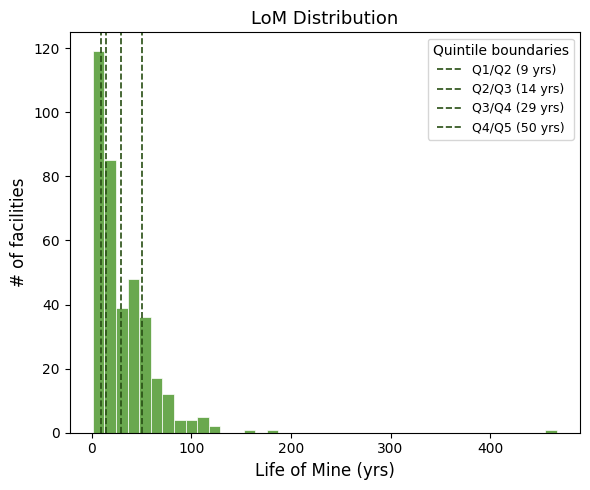

In [49]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.hist(
    mother_file["LOM_in_Buckets"].dropna(),
    bins=40,
    color="#6aa84fff",
    edgecolor="white",
    linewidth=0.5,
)

# Quintile boundary lines
quintile_edges = mother_file["LOM_in_Buckets"].quantile([0.2, 0.4, 0.6, 0.8])
labels = ["Q1/Q2", "Q2/Q3", "Q3/Q4", "Q4/Q5"]
for val, lbl in zip(quintile_edges, labels):
    ax.axvline(val, color="#274e13", linestyle="--", linewidth=1.2, label=f"{lbl} ({val:.0f} yrs)")

ax.set_xlabel("Life of Mine (yrs)", fontsize=12)
ax.set_ylabel("# of facilities", fontsize=12)
ax.set_title("LoM Distribution", fontsize=13)
ax.legend(title="Quintile boundaries", fontsize=9)

plt.tight_layout()
# plt.savefig("lom_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [50]:
# Split on facility_id
facilities = mother_file["facility_id"].unique()
train_facilities, test_facilities = train_test_split(facilities, test_size=0.2, random_state=42)

train_df = mother_file[mother_file["facility_id"].isin(train_facilities)]
test_df  = mother_file[mother_file["facility_id"].isin(test_facilities)]

print(f"Train rows : {len(train_df)} ({len(train_facilities)} facilities)")
print(f"Test rows  : {len(test_df)} ({len(test_facilities)} facilities)")

# Extract target variable
y_train = train_df["LOM_quintile"]
y_test  = test_df["LOM_quintile"]
drop_cols = [
    "LOM_in_Buckets",   
    "LOM_quintile",     
    "facility_id",      
    "primary_commodity",# already one-hot encoded in the dataset
    "country",          # already one-hot encoded in the dataset
]
# Drop unwanted columns (found after other data processing steps)to create feature matrices
X_train = train_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")
X_test  = test_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")

#we had a problem with infinite values accidentally :( 
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Drop rows where target variable doesn't exist
mask_train = y_train.notna()
mask_test  = y_test.notna()
X_train, y_train = X_train[mask_train], y_train[mask_train]
X_test,  y_test  = X_test[mask_test],  y_test[mask_test]

# Fill NaNs in features with training median
# X_train = X_train.fillna(X_train.median())
# X_test  = X_test.fillna(X_train.median())

print(f"\nFeatures used : {list(X_train.columns)}")
print(f"Train samples : {len(X_train)}")
print(f"Test samples  : {len(X_test)}")

Train rows : 299 (299 facilities)
Test rows  : 75 (75 facilities)

Features used : ['total_reserves_minerals', 'total_reserves_commodities', 'avg_reserves_grade_ppm', 'avg_commodity_recovery_rate', 'avg_commodities_grade_ppm', 'total_coal', 'total_commodities', 'total_minerals', 'mining_salary', 'still_operating', '2000_Concentrate', '2001_Concentrate', '2002_Concentrate', '2003_Concentrate', '2004_Concentrate', '2005_Concentrate', '2006_Concentrate', '2007_Concentrate', '2008_Concentrate', '2009_Concentrate', '2010_Concentrate', '2011_Concentrate', '2012_Concentrate', '2013_Concentrate', '2014_Concentrate', '2015_Concentrate', '2016_Concentrate', '2017_Concentrate', '2018_Concentrate', '2019_Concentrate', '2020_Concentrate', '2000_price_usd_tonne', '2001_price_usd_tonne', '2002_price_usd_tonne', '2003_price_usd_tonne', '2004_price_usd_tonne', '2005_price_usd_tonne', '2006_price_usd_tonne', '2007_price_usd_tonne', '2008_price_usd_tonne', '2009_price_usd_tonne', '2010_price_usd_tonne', 

In [51]:
# for the classifier
y_train_c = train_df["LOM_quintile"]
y_test_c  = test_df["LOM_quintile"]
print(y_train_c)

mask_train = y_train_c.notna()
mask_test  = y_test_c.notna()
X_train, y_train_c = X_train[mask_train], y_train_c[mask_train]
X_test,  y_test_c  = X_test[mask_test],  y_test_c[mask_test]


1      Q3
2      Q1
4      Q1
6      Q2
7      Q2
       ..
367    Q4
368    Q5
369    Q5
371    Q2
373    Q5
Name: LOM_quintile, Length: 299, dtype: category
Categories (5, str): ['Q1' < 'Q2' < 'Q3' < 'Q4' < 'Q5']


# RandomForest Classifier

In [52]:
print(y_train_c.nunique())       # sanity check because i am going insane
print(y_train_c.value_counts())

5
LOM_quintile
Q1    63
Q4    61
Q2    60
Q5    58
Q3    57
Name: count, dtype: int64


In [53]:
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",   # handles any class imbalance from uneven quintiles
    random_state=42,
    n_jobs=-1,
)
clf.fit(X_train, y_train_c)

y_pred_clf = clf.predict(X_test)
print(accuracy_score(y_test_c,y_pred_clf))
print(classification_report(y_test_c, y_pred_clf))

0.6133333333333333
              precision    recall  f1-score   support

          Q1       0.67      0.71      0.69        14
          Q2       0.71      0.75      0.73        16
          Q3       0.71      0.59      0.65        17
          Q4       0.35      0.55      0.43        11
          Q5       0.67      0.47      0.55        17

    accuracy                           0.61        75
   macro avg       0.62      0.61      0.61        75
weighted avg       0.64      0.61      0.62        75



In [54]:
importances = (
    pd.Series(clf.feature_importances_, index=X_test.columns)
    .sort_values(ascending=False)
    .head(15)
)
print("Top 15 feature importances:")
for feat, imp in importances.items():
    bar = "█" * int(imp * 300)
    print(f"  {feat:<45} {imp:.4f}  {bar}")
 

Top 15 feature importances:
  total_reserves_minerals                       0.0506  ███████████████
  2011_price_usd_tonne                          0.0479  ██████████████
  2013_price_usd_tonne                          0.0449  █████████████
  2012_price_usd_tonne                          0.0437  █████████████
  2006_price_usd_tonne                          0.0373  ███████████
  mining_salary                                 0.0365  ██████████
  2019_price_usd_tonne                          0.0362  ██████████
  total_coal                                    0.0358  ██████████
  avg_commodities_grade_ppm                     0.0353  ██████████
  2008_price_usd_tonne                          0.0317  █████████
  2010_price_usd_tonne                          0.0303  █████████
  total_minerals                                0.0294  ████████
  2018_price_usd_tonne                          0.0290  ████████
  total_commodities                             0.0288  ████████
  2005_price_usd_tonne    

In [56]:
#cross validation
X_full = pd.concat([X_train, X_test])
y_full_c = pd.concat([y_train_c, y_test_c])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(clf, X_full, y_full_c, cv=cv, scoring="accuracy")

print("Per-fold accuracy:", np.round(scores, 3))
print(f"Mean accuracy   : {scores.mean():.3f}")
print(f"Std             : {scores.std():.3f}")

Per-fold accuracy: [0.6   0.64  0.627 0.52  0.527]
Mean accuracy   : 0.583
Std             : 0.050


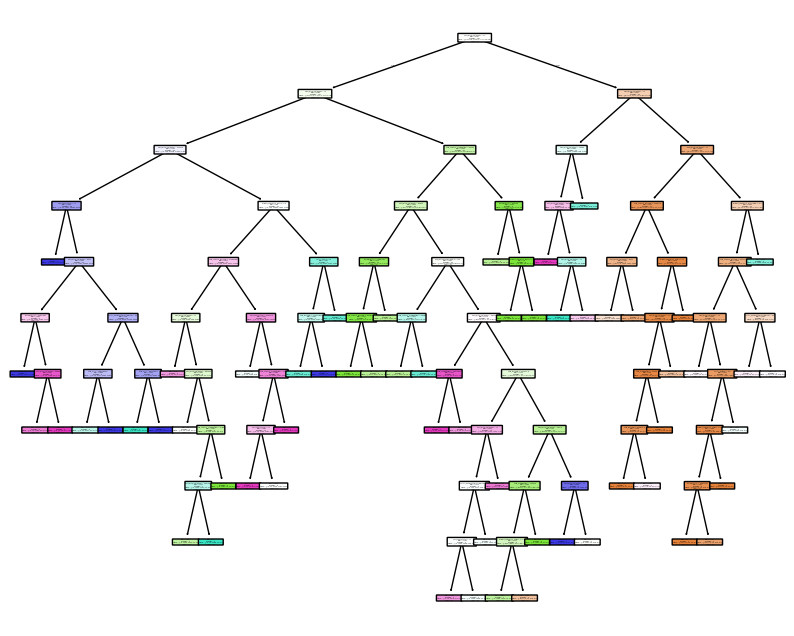

In [57]:
#let's plot this bad boy
single_tree = clf.estimators_[0]
fig, ax = plt.subplots(figsize=(10,8))

plot_tree(
    single_tree,
    feature_names=X_train.columns,
    class_names=clf.classes_,
    filled=True,
    rounded=True,
    # max_depth=3,
    ax=ax,
)

# plt.tight_layout()
# plt.savefig("lom_example_tree.png", dpi=150, bbox_inches="tight")
plt.show()

### Gradient Boosting for Basic RF Classifier

In [ ]:
# ── 1. Define model ────────────────────────────────────────────────────────────
gb_clf = HistGradientBoostingClassifier(random_state=42) # normal grad boosting had too many NaNs and couldn't deal with it :( 

# ── 2. Hyperparameter grid ─────────────────────────────────────────────────────
param_grid = {
    "max_iter":        [100, 200, 300],   
    "max_depth":       [3, 5, 7],
    "learning_rate":   [0.01, 0.05, 0.1],
    "max_leaf_nodes":  [31, 63],          
    "min_samples_leaf":[1, 2, 5],
}

# ── 3. Grid search with stratified CV ─────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gb_grid = GridSearchCV(
    gb_clf,
    param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)

gb_grid.fit(X_train, y_train_c)
# ── 4. Evaluate ────────────────────────────────────────────────────────────────
print(f"Best params   : {gb_grid.best_params_}")
print(f"Best CV score : {gb_grid.best_score_:.3f}")
print()

y_pred_gb = gb_grid.predict(X_test)
print(f"Test accuracy : {accuracy_score(y_test_c, y_pred_gb):.3f}")
print()
print("Classification report:")
print(classification_report(y_test_c, y_pred_gb, target_names=gb_grid.classes_))

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best params   : {'learning_rate': 0.05, 'max_depth': 3, 'max_iter': 200, 'max_leaf_nodes': 31, 'min_samples_leaf': 1}
Best CV score : 0.555

Test accuracy : 0.560

Classification report:
              precision    recall  f1-score   support

          Q1       0.73      0.57      0.64        14
          Q2       0.60      0.56      0.58        16
          Q3       0.67      0.59      0.62        17
          Q4       0.26      0.45      0.33        11
          Q5       0.67      0.59      0.62        17

    accuracy                           0.56        75
   macro avg       0.58      0.55      0.56        75
weighted avg       0.60      0.56      0.58        75



# For Loop Different Feature Combinations

### drop the waste for the year based data and load it in

In [90]:
drop_bases = ['waste_total_material_tonnes', 'waste_value_tonnes','Concentrate','Ore processed','LOM_in_Buckets']
mother_file = pd.read_csv('data/one_hot_mama.csv')
cols_to_drop = [
    col for col in mother_file.columns
    if any(col == base or col.endswith(f'_{base}') or col.startswith(f'{base}_') for base in drop_bases)
]
mother_file = mother_file.drop(columns=cols_to_drop, errors='ignore')
print(f'Dropped {len(cols_to_drop)} columns: {cols_to_drop}')
mother_file.to_csv('data/one_hot_mama.csv', index=False)

Dropped 0 columns: []


In [56]:
import re
from itertools import combinations
mother_file =  pd.read_csv('data/average_data.csv')
# Group year-prefixed columns and one-hot encoded categories by their base feature name.
YEAR_PREFIX_RE = re.compile(r'^(\d{4})_(.+)$')
def base_feature_name(column_name): #features that are one-hot encoded 
    match = YEAR_PREFIX_RE.match(column_name)
    if match:
        return match.group(2)
    if column_name.startswith('country_'):
        return 'country'
    if column_name.startswith('primary_commodity_'):
        return 'primary_commodity'
    return column_name

numeric_feature_cols = [ #extract all the numeric feature columns except the target variable
    col for col in mother_file.select_dtypes(include='number').columns
    if col != 'LOM_in_Buckets'
]
# numeric_feature_cols = [ #extract all the numeric feature columns except the target variable
#     col for col in mother_file.select_dtypes(include='number').columns
#     if col != 'LOM_quintile'
# ]
feature_groups = {}
for col in numeric_feature_cols:
    group_name = base_feature_name(col)
    feature_groups.setdefault(group_name, []).append(col)

print(f"Found {len(feature_groups)} numeric feature groups")
for group_name, cols in sorted(feature_groups.items(), key=lambda item: (-len(item[1]), item[0])):
    print(f"{group_name}: {len(cols)} columns")

feature_group_names = sorted(feature_groups)


Found 13 numeric feature groups
country: 46 columns
coal_mined_value_tonnes: 21 columns
commodities_grade_ppm: 21 columns
commodities_recovery_rate: 21 columns
commodities_value_tonnes: 21 columns
minerals_ore_mined_value_tonnes: 21 columns
price_usd_tonne: 21 columns
reserves_mineral_value_tonnes: 21 columns
reserves_commodity_value_tonnes: 15 columns
reserves_grade_ppm: 15 columns
primary_commodity: 10 columns
mining_salary: 1 columns
still_operating: 1 columns


In [89]:
drop_bases = ['waste_total_material_tonnes', 'waste_value_tonnes','Concentrate','Ore processed']
mother_file = pd.read_csv('data/for_loop_data.csv')
cols_to_drop = [
    col for col in mother_file.columns
    if any(col == base or col.endswith(f'_{base}') or col.startswith(f'{base}_') for base in drop_bases)
]
mother_file = mother_file.drop(columns=cols_to_drop, errors='ignore')

print(f'Dropped {len(cols_to_drop)} columns: {cols_to_drop}')
mother_file.to_csv('data/average_data.csv', index=False)

Dropped 21 columns: ['2000_Concentrate', '2001_Concentrate', '2002_Concentrate', '2003_Concentrate', '2004_Concentrate', '2005_Concentrate', '2006_Concentrate', '2007_Concentrate', '2008_Concentrate', '2009_Concentrate', '2010_Concentrate', '2011_Concentrate', '2012_Concentrate', '2013_Concentrate', '2014_Concentrate', '2015_Concentrate', '2016_Concentrate', '2017_Concentrate', '2018_Concentrate', '2019_Concentrate', '2020_Concentrate']


In [ ]:
drop_bases = ['waste_total_material_tonnes', 'waste_value_tonnes','Concentrate','Ore processed']
mother_file = pd.read_csv('data/for_loop_data.csv')
cols_to_drop = [
    col for col in mother_file.columns
    if any(col == base or col.endswith(f'_{base}') or col.startswith(f'{base}_') for base in drop_bases)
]
mother_file = mother_file.drop(columns=cols_to_drop, errors='ignore')

print(f'Dropped {len(cols_to_drop)} columns: {cols_to_drop}')

# Average price_usd_tonne columns per facility_id (row)
price_cols = [col for col in mother_file.columns if 'price_usd_tonne' in col]
if price_cols:
    # Replace 0 with NaN and compute row-wise mean (ignoring NaN)
    mother_file['avg_price_usd_tonnes'] = mother_file[price_cols].replace(0, np.nan).mean(axis=1)
    # Drop the original year-based price columns
    mother_file = mother_file.drop(columns=price_cols, errors='ignore')
    print(f'Averaged {len(price_cols)} price_usd_tonne columns into avg_price_usd_tonnes')

mother_file.to_csv('data/average_data.csv', index=False)
    'commodities_value_tonnes',
    'coal_mined_value_tonnes',
    'commodities_grade_ppm',
    'commodities_recovery_rate',
]

remaining_groups = [
    g for g in feature_group_names
    if g not in preferred_order and g not in {'facility_id', 'LOM_quintile'}
]

search_groups = [g for g in preferred_order if g in feature_group_names] + remaining_groups
print(f"Searching combinations over {len(search_groups)} feature groups")

best_results = []
max_results = 20
for r in range(1, min(4, len(search_groups)) + 1):
    for combo in combinations(search_groups, r):
        selected_cols = [col for group in combo for col in feature_groups[group]]
        X_train_combo = train_df[selected_cols].select_dtypes(include='number').copy()
        X_test_combo = test_df[selected_cols].select_dtypes(include='number').copy()

        X_train_combo = X_train_combo.replace([np.inf, -np.inf], np.nan)
        X_test_combo = X_test_combo.replace([np.inf, -np.inf], np.nan)


        # # CLASSIFIER
        # model_combo = RandomForestClassifier(
        #     n_estimators=100,
        #     max_depth=None,
        #     min_samples_leaf=2,
        #     class_weight="balanced",   # handles any class imbalance from uneven quintiles
        #     random_state=42,
        #     n_jobs=-1,
        # )
        # model_combo.fit(X_train_combo, y_train)
        # y_pred = model_combo.predict(X_test_combo)

        # accuracy = accuracy_score(y_test, y_pred)
        # balanced_acc = balanced_accuracy_score(y_test, y_pred)
        # report = classification_report(y_test, y_pred, output_dict=True)
        # f1_w = report['weighted avg']['f1-score']

        # record = {
        #     'feature_groups': combo,
        #     'num_columns': len(selected_cols),
        #     'accuracy': accuracy,
        #     'balanced_accuracy': balanced_acc,
        #     'f1_weighted': f1_w,
        #     'precision_weighted': report['weighted avg']['precision'],
        #     'recall_weighted': report['weighted avg']['recall'],
        # }

        # REGRESSOR
        model_combo = RandomForestRegressor(random_state=42, n_estimators=100)
        model_combo.fit(X_train_combo, y_train)
        score = r2_score(y_test, model_combo.predict(X_test_combo))

        record = {
            'feature_groups': combo,
            'num_columns': len(selected_cols),
            'r2_test': score,
        }

        if len(best_results) < max_results:
            heapq.heappush(best_results, (f1_w, record))
        else:
            heapq.heappushpop(best_results, (f1_w, record))

best_sorted = [record for score, record in sorted(best_results, key=lambda x: x[0], reverse=True)]
combo_df = pd.DataFrame(best_sorted)
print(combo_df.to_string(index=False))

# Save only the top results to keep the output file small.
combo_df.to_csv('data/feature_group_combo_results.csv', index=False)
print('Saved top 20 feature-group combo results to data/feature_group_combo_results.csv')

Dropped 21 columns: ['2000_Concentrate', '2001_Concentrate', '2002_Concentrate', '2003_Concentrate', '2004_Concentrate', '2005_Concentrate', '2006_Concentrate', '2007_Concentrate', '2008_Concentrate', '2009_Concentrate', '2010_Concentrate', '2011_Concentrate', '2012_Concentrate', '2013_Concentrate', '2014_Concentrate', '2015_Concentrate', '2016_Concentrate', '2017_Concentrate', '2018_Concentrate', '2019_Concentrate', '2020_Concentrate']
374
[]


In [40]:
# Save the best model's training and test data
best_combo = best_sorted[0]['feature_groups']
best_combo_cols = [col for group in best_combo for col in feature_groups[group]]

X_train_best = train_df[best_combo_cols].select_dtypes(include='number').copy()
X_test_best = test_df[best_combo_cols].select_dtypes(include='number').copy()

X_train_best = X_train_best.replace([np.inf, -np.inf], np.nan)
X_test_best = X_test_best.replace([np.inf, -np.inf], np.nan)

y_train_best = y_train
y_test_best = y_test

# Save to CSV files
# X_train_best.to_csv('data/best_X_train.csv', index=False)
# X_test_best.to_csv('data/best_X_test.csv', index=False)
# y_train_best.to_csv('data/best_y_train.csv', index=False)
# y_test_best.to_csv('data/best_y_test.csv', index=False)

print(f"Saved best model data:")
print(f"  Best feature groups: {best_combo}")
print(f"  X_train shape: {X_train_best.shape}")
print(f"  X_test shape: {X_test_best.shape}")
print(f"  y_train shape: {y_train_best.shape}")
print(f"  y_test shape: {y_test_best.shape}")
#print(f"  Best R^2: {best_sorted[0]['r2_test']}")
print(f"  Best F1-weighted: {best_sorted[0]['f1_weighted']:.4f}")
print(f"  Best accuracy: {best_sorted[0]['accuracy']:.4f}")

Saved best model data:
  Best feature groups: ('reserves_commodity_value_tonnes', 'reserves_mineral_value_tonnes', 'reserves_grade_ppm', 'coal_mined_value_tonnes')
  X_train shape: (321, 72)
  X_test shape: (81, 72)
  y_train shape: (321,)
  y_test shape: (81,)
  Best R^2: 0.19380574729454325


# Plot For Loop Model

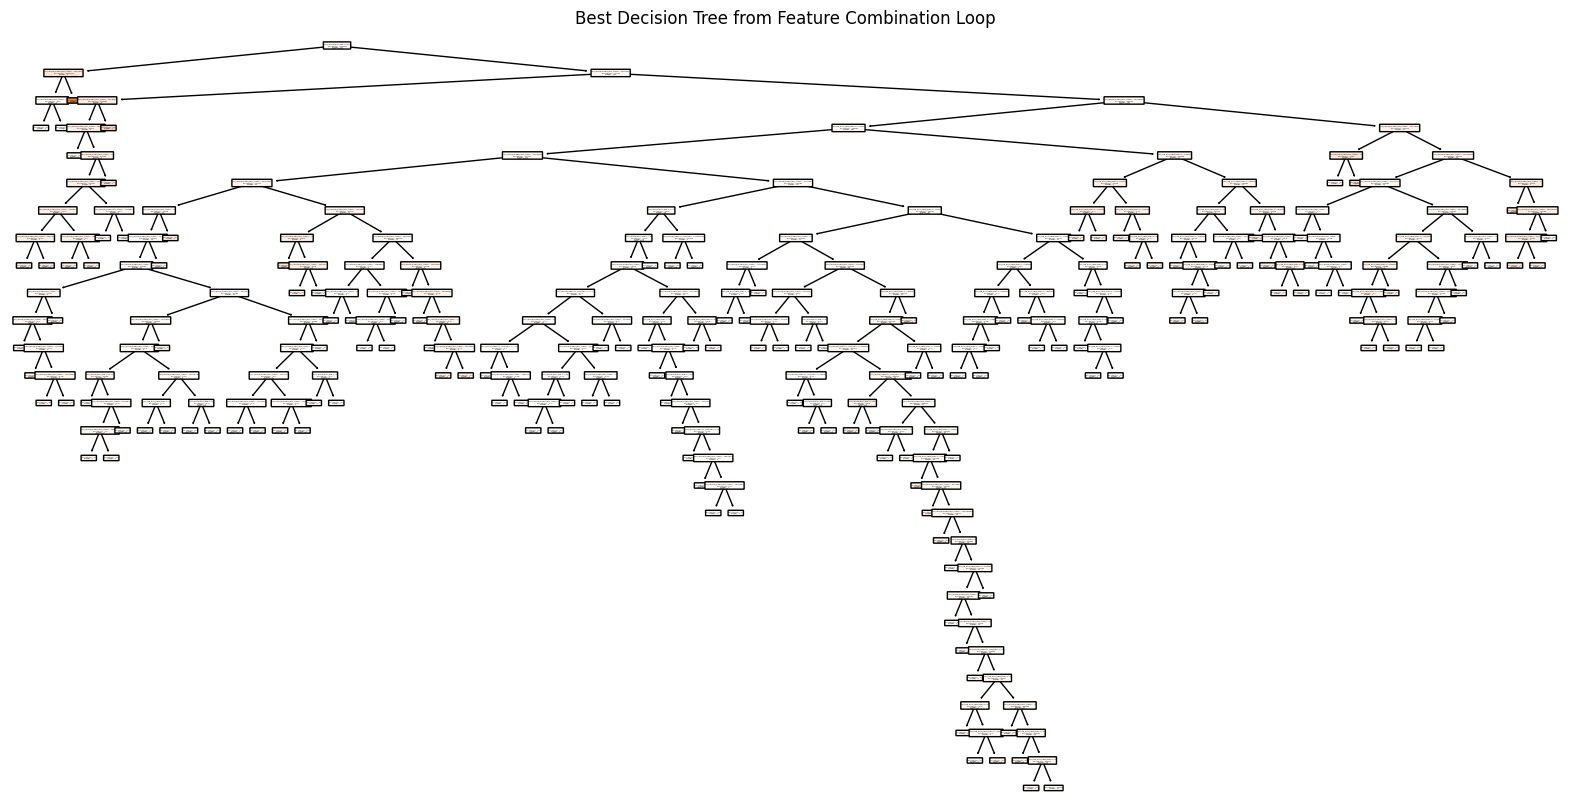

In [41]:
# Plot the best decision tree from the feature combination loop
best_tree_model = RandomForestClassifier(random_state=42, n_estimators=100)
best_tree_model.fit(X_train_best, y_train_best)

best_tree = best_tree_model.estimators_[0]

plt.figure(figsize=(20,10)) 
plot_tree(best_tree,
          filled=True,              
          feature_names=X_train_best.columns.tolist(),
          rounded=True)             
plt.title("Best Decision Tree from Feature Combination Loop")
plt.show()


In [ ]:
# we're having some trouble with X, let's see what it is -- as it turns out, some values were infinite
#print(X_train)
pd.DataFrame(X_train).to_csv('data/X_train_check.csv', index=False)

# Base Model with Random Forest

In [40]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
# print(y_pred_train)
# print(y_pred_test)

print('R^2 train:', r2_score(y_train, y_pred_train))
print('R^2 test :', r2_score(y_test, y_pred_test))

# accuracy_train_grid = accuracy_score(y_train, y_pred_train)
# accuracy_test_grid = accuracy_score(y_test, y_pred_test)


R^2 train: 0.8547012695960857
R^2 test : 0.07013480789548754


## Gradient Boosting

In [ ]:
# ── 1. Define model ────────────────────────────────────────────────────────────
gb_clf = HistGradientBoostingClassifier(random_state=42) # normal grad boosting had too many NaNs and couldn't deal with it :( 

# ── 2. Hyperparameter grid ─────────────────────────────────────────────────────
param_grid = {
    "max_iter":        [100, 200, 300],   
    "max_depth":       [3, 5, 7],
    "learning_rate":   [0.01, 0.05, 0.1],
    "max_leaf_nodes":  [31, 63],          
    "min_samples_leaf":[1, 2, 5],
}

# ── 3. Grid search with stratified CV ─────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gb_grid = GridSearchCV(
    gb_clf,
    param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)

gb_grid.fit(X_train, y_train_c)

# ── 4. Evaluate ────────────────────────────────────────────────────────────────
print(f"Best params   : {gb_grid.best_params_}")
print(f"Best CV score : {gb_grid.best_score_:.3f}")
print()

y_pred_gb = gb_grid.predict(X_test)
print(f"Test accuracy : {accuracy_score(y_test_c, y_pred_gb):.3f}")
print()
print("Classification report:")
print(classification_report(y_test_c, y_pred_gb, target_names=gb_grid.classes_))


Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best params   : {'learning_rate': 0.01, 'max_depth': 7, 'max_iter': 200, 'max_leaf_nodes': 31, 'min_samples_leaf': 2}
Best CV score : 0.470

Test accuracy : 0.395

Classification report:
              precision    recall  f1-score   support

          Q1       0.48      0.78      0.60        18
          Q2       0.50      0.36      0.42        14
          Q3       0.17      0.12      0.14        17
          Q4       0.35      0.50      0.41        12
          Q5       0.38      0.25      0.30        20

    accuracy                           0.40        81
   macro avg       0.38      0.40      0.37        81
weighted avg       0.38      0.40      0.37        81



ValueError: Classification metrics can't handle a mix of multiclass and continuous targets

In [59]:
# ── 5. Compare against your RF ────────────────────────────────────────────────
y_pred_rf = clf.predict(X_test)
print("=" * 40)
print(f"RF accuracy : {accuracy_score(y_test_c, y_pred_rf):.3f}")
print(f"GB accuracy : {accuracy_score(y_test_c, y_pred_gb):.3f}")

RF accuracy : 0.420
GB accuracy : 0.395


# Average Data Instead of Year-by-Year

In [59]:
avg_df = pd.read_csv('data/average_data.csv')
avg_df

,facility_id,total_reserves_minerals,total_reserves_commodities,avg_reserves_grade_ppm,avg_commodity_recovery_rate,avg_commodities_grade_ppm,total_coal,total_commodities,total_minerals,primary_commodity,...,primary_commodity_Copper,primary_commodity_Gold,primary_commodity_Iron,primary_commodity_Nickel,primary_commodity_Other (poly)-metallic,primary_commodity_Other mine,primary_commodity_Silver,primary_commodity_Zinc,avg_price_usd,commodity_var
0,COM00003.00,1.094375e+09,0.000000,NaN,NaN,NaN,85716792.0,0.000,0.0,Coal,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,69.988824,35.474096
1,COM00009.00,2.961694e+09,273.289402,1.594967,0.920600,1.873773,0.0,184.360,129637066.0,Gold,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,19845.493636,44.618964
2,COM00015.00,1.399000e+09,0.000000,NaN,NaN,149375.257990,0.0,196800.000,48136000.0,Copper,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1165.624286,36.279669
3,COM00016.00,6.189506e+08,73.141769,1.216045,0.913600,1.700082,0.0,80.851,61959946.0,Gold,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,5920.252000,44.618964
4,COM00017.00,1.184937e+09,0.000000,NaN,NaN,NaN,0.0,0.000,19521911.0,Aluminium,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1272.545714,16.735645
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,COM01415.00,0.000000e+00,0.000000,NaN,NaN,NaN,35811100.0,0.000,0.0,Coal,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,35.474096
370,COM01418.00,0.000000e+00,9.896000,7.880000,NaN,NaN,0.0,20.241,0.0,Gold,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,44.618964
371,COM01419.00,2.500000e+07,0.000000,NaN,NaN,NaN,31357000.0,0.000,0.0,Coal,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5428.443500,35.474096
372,COM01430.00,0.000000e+00,0.357000,0.320000,NaN,NaN,0.0,239.953,0.0,Gold,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,64.580000,44.618964


In [60]:
# dividing average data into quintiles
avg_df["LOM_quintile"] = pd.qcut(
    avg_df["LOM_in_Buckets"],
    q=5,
    labels=["Q1", "Q2", "Q3", "Q4", "Q5"],
    duplicates="drop",
)
 
print("Records per quintile bin:")
print(avg_df["LOM_quintile"].value_counts().sort_index().to_string())
print()
 
# Bin ranges for reference
print("Bin value ranges:")
for bin_name in avg_df["LOM_quintile"].cat.categories:
    subset = avg_df.loc[avg_df["LOM_quintile"] == bin_name, "LOM_in_Buckets"]
    print(f"  {bin_name:<18} → [{subset.min():.0f}, {subset.max():.0f}] yrs  (n={len(subset)})")
print()

facilities = avg_df["facility_id"].unique()
train_facilities, test_facilities = train_test_split(facilities, test_size=0.2, random_state=42)

train_df = avg_df[avg_df["facility_id"].isin(train_facilities)]
test_df  = avg_df[avg_df["facility_id"].isin(test_facilities)]

print(f"Train rows : {len(train_df)} ({len(train_facilities)} facilities)")
print(f"Test rows  : {len(test_df)} ({len(test_facilities)} facilities)")

# Extract target variable
y_train_c = train_df["LOM_quintile"]
y_test_c  = test_df["LOM_quintile"]
drop_cols = [
    "LOM_in_Buckets",   
    "LOM_quintile",     
    "facility_id",      
    "primary_commodity",# already one-hot encoded in the dataset
    "country",          # already one-hot encoded in the dataset
]
# Drop unwanted columns (found after other data processing steps)to create feature matrices
X_train = train_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")
X_test  = test_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")

#we had a problem with infinite values accidentally :( 
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Drop rows where target variable doesn't exist
mask_train = y_train_c.notna()
mask_test  = y_test_c.notna()
X_train, y_train_c = X_train[mask_train], y_train_c[mask_train]
X_test,  y_test_c  = X_test[mask_test],  y_test_c[mask_test]

# Fill NaNs in features with training median
# X_train = X_train.fillna(X_train.median())
# X_test  = X_test.fillna(X_train.median())

print(f"\nFeatures used : {list(X_train.columns)}")
print(f"Train samples : {len(X_train)}")
print(f"Test samples  : {len(X_test)}")

Records per quintile bin:
LOM_quintile
Q1    77
Q2    76
Q3    74
Q4    72
Q5    75

Bin value ranges:
  Q1                 → [1, 9] yrs  (n=77)
  Q2                 → [10, 14] yrs  (n=76)
  Q3                 → [15, 29] yrs  (n=74)
  Q4                 → [30, 50] yrs  (n=72)
  Q5                 → [51, 467] yrs  (n=75)

Train rows : 299 (299 facilities)
Test rows  : 75 (75 facilities)

Features used : ['total_reserves_minerals', 'total_reserves_commodities', 'avg_reserves_grade_ppm', 'avg_commodity_recovery_rate', 'avg_commodities_grade_ppm', 'total_coal', 'total_commodities', 'total_minerals', 'mining_salary', 'still_operating', 'country_Argentina', 'country_Australia', 'country_Bolivia', 'country_Bosnia and Herzegovina', 'country_Brazil', 'country_Canada', 'country_Chile', 'country_China', 'country_Colombia', "country_Cote d'Ivoire", 'country_Cuba', 'country_DR Congo', 'country_Dominican Republic', 'country_Finland', 'country_Ghana', 'country_Guatemala', 'country_Guinea', 'country_I

In [61]:
# actual model, yay!

c_avg = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",   # handles any class imbalance from uneven quintiles
    random_state=42,
    n_jobs=-1,
)
c_avg.fit(X_train, y_train_c)

y_pred_c_avg = c_avg.predict(X_test)
print(accuracy_score(y_test_c,y_pred_c_avg))
print(classification_report(y_test_c, y_pred_c_avg))

0.3333333333333333
              precision    recall  f1-score   support

          Q1       0.17      0.14      0.15        14
          Q2       0.50      0.31      0.38        16
          Q3       0.41      0.41      0.41        17
          Q4       0.17      0.27      0.21        11
          Q5       0.44      0.47      0.46        17

    accuracy                           0.33        75
   macro avg       0.34      0.32      0.32        75
weighted avg       0.36      0.33      0.34        75



In [62]:
importances = (
    pd.Series(c_avg.feature_importances_, index=X_test.columns)
    .sort_values(ascending=False)
    .head(15)
)
print("Top 15 feature importances:")
for feat, imp in importances.items():
    bar = "█" * int(imp * 300)
    print(f"  {feat:<45} {imp:.4f}  {bar}")
 

Top 15 feature importances:
  avg_price_usd                                 0.1286  ██████████████████████████████████████
  total_reserves_minerals                       0.1101  █████████████████████████████████
  total_coal                                    0.0866  █████████████████████████
  avg_commodities_grade_ppm                     0.0782  ███████████████████████
  mining_salary                                 0.0757  ██████████████████████
  total_commodities                             0.0731  █████████████████████
  total_minerals                                0.0729  █████████████████████
  avg_commodity_recovery_rate                   0.0484  ██████████████
  commodity_var                                 0.0434  █████████████
  avg_reserves_grade_ppm                        0.0358  ██████████
  total_reserves_commodities                    0.0324  █████████
  country_Indonesia                             0.0213  ██████
  country_United States of America              0.020